# ARTI403 – Image Processing
## Lab 1: Basics of Programming with Python – Image Loading, Visualization, Storage, and Array Operations

**Outcome #1:** Explain how digital images are represented and manipulated in a computer.

**Student Name:** *(Abdullah Hejji Alnuwaysir)*
**Course:** ARTI403 – Image Processing
**Lab:** Lab 1


## Task #1: Exercise with Spyder (Python Basics)

A quick warm-up with core Python / NumPy syntax before moving to image work.


In [1]:
# Basic Python / NumPy warm-up exercise (Task #1)
import numpy as np

# simple variables and operations
a = 10
b = 3
print("a + b =", a + b)
print("a / b =", a / b)
print("a // b =", a // b)
print("a % b =", a % b)

# a small NumPy array to warm up
warmup = np.arange(1, 11)
print("\nArray:", warmup)
print("Sum:", warmup.sum())
print("Mean:", warmup.mean())
print("Reshaped (2x5):\n", warmup.reshape(2, 5))


a + b = 13
a / b = 3.3333333333333335
a // b = 3
a % b = 1

Array: [ 1  2  3  4  5  6  7  8  9 10]
Sum: 55
Mean: 5.5
Reshaped (2x5):
 [[ 1  2  3  4  5]
 [ 6  7  8  9 10]]


## Task #2: Loading and Visualizing Images

### a) Loading/reading an image using OpenCV


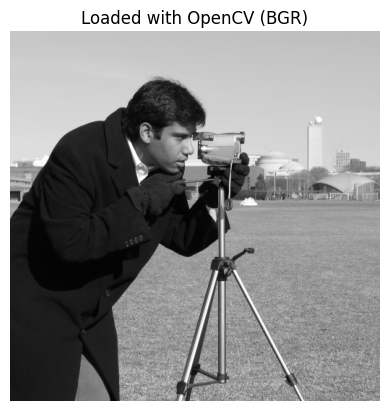

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('images/cameraman.tif')  # Load the image data into a NumPy array
plt.imshow(img)
plt.title("Loaded with OpenCV (BGR)")
plt.axis('off')
plt.show()


> **Note:** OpenCV loads images in **BGR** order (not RGB), so colors can look slightly
> off when displayed directly with Matplotlib. This is expected and is explained further below.

### b) Loading/reading image using PIL


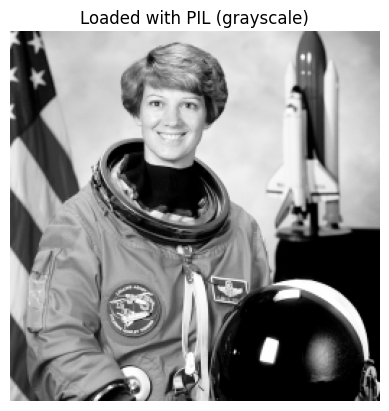

In [3]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

img2 = Image.open('images/lena_gray_256.tif')  # load image into a PIL Image object
plt.imshow(img2, cmap=cm.Greys_r)
plt.title("Loaded with PIL (grayscale)")
plt.axis('off')
plt.show()


## Task #3: Image Storing

### a) Saving image to disk using OpenCV


In [4]:
cv2.imwrite('new_image.jpg', img)
print("Saved 'new_image.jpg' using OpenCV")


Saved 'new_image.jpg' using OpenCV


### b) Saving an image to disk using PIL

In [5]:
img2.save('new_image2.jpg')
print("Saved 'new_image2.jpg' using PIL")


Saved 'new_image2.jpg' using PIL


## Task #4: Display Image as an Array


In [6]:
print("Shape of img (OpenCV array):", img.shape)  # Note: img loaded using OpenCV is a NumPy array
print(img)


Shape of img (OpenCV array): (512, 512, 3)
[[[200 200 200]
  [200 200 200]
  [200 200 200]
  ...
  [189 189 189]
  [190 190 190]
  [190 190 190]]

 [[200 200 200]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 ...

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [139 139 139]
  [122 122 122]
  [147 147 147]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 26  26  26]
  ...
  [158 158 158]
  [141 141 141]
  [168 168 168]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [151 151 151]
  [152 152 152]
  [149 149 149]]]


In [7]:
import numpy as np

# Convert the PIL image to a NumPy array
img_array = np.array(img2)

# Print the array
print("Shape of img_array (from PIL):", img_array.shape)
print(img_array)


Shape of img_array (from PIL): (256, 256)
[[143  86 113 ... 121 121 118]
 [200 179 185 ... 119 120 118]
 [227 218 213 ... 120 120 119]
 ...
 [174 176 170 ...  62  25   0]
 [176 172 162 ...  47   1   0]
 [172 166 148 ...  84  21   1]]


## 4- Assessment: NumPy Array Operations on the Image

The manual states: *"The student will be asked to perform different operations on the array
using the NumPy library."* Below is a set of common operations performed on `img_array`
(the grayscale image loaded via PIL), covering shape/type inspection, indexing & slicing,
arithmetic, geometric transforms, and basic statistics.


### 1) Basic inspection

In [8]:
print("Shape :", img_array.shape)
print("Dtype :", img_array.dtype)
print("Size (total pixels):", img_array.size)
print("Number of dimensions:", img_array.ndim)


Shape : (256, 256)
Dtype : uint8
Size (total pixels): 65536
Number of dimensions: 2


### 2) Indexing & slicing (crop a region + extract a single pixel)

Pixel value at (100, 100): 9
Cropped shape: (100, 100)


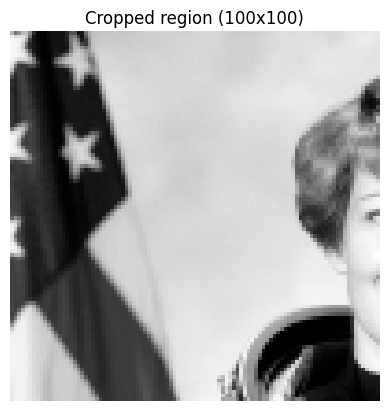

In [9]:
# Value of a single pixel at row 100, column 100
pixel_value = img_array[100, 100]
print("Pixel value at (100, 100):", pixel_value)

# Crop the top-left 100x100 region
cropped = img_array[0:100, 0:100]
print("Cropped shape:", cropped.shape)

plt.imshow(cropped, cmap=cm.Greys_r)
plt.title("Cropped region (100x100)")
plt.axis('off')
plt.show()


### 3) Flipping and rotating the array

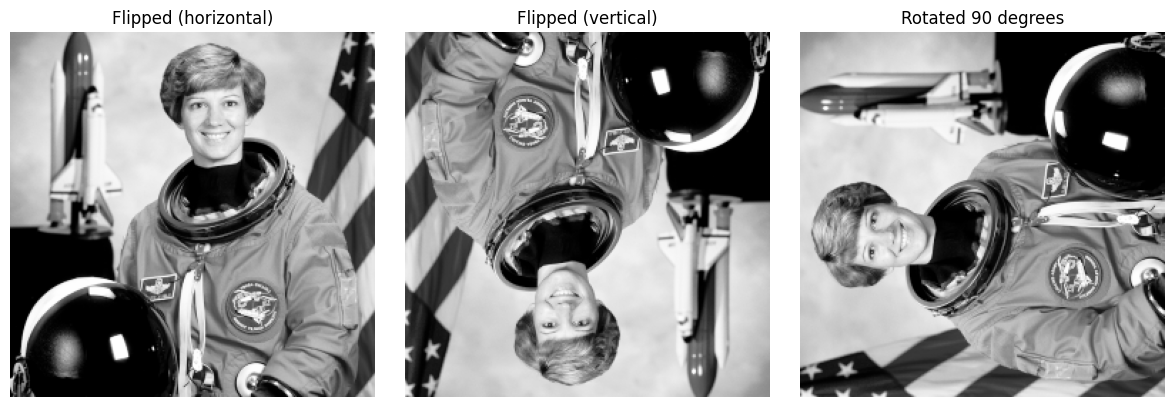

In [10]:
flipped_horizontal = np.fliplr(img_array)   # flip left-right
flipped_vertical = np.flipud(img_array)      # flip top-bottom
rotated_90 = np.rot90(img_array)             # rotate 90 degrees

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(flipped_horizontal, cmap=cm.Greys_r); axes[0].set_title("Flipped (horizontal)"); axes[0].axis('off')
axes[1].imshow(flipped_vertical, cmap=cm.Greys_r); axes[1].set_title("Flipped (vertical)"); axes[1].axis('off')
axes[2].imshow(rotated_90, cmap=cm.Greys_r); axes[2].set_title("Rotated 90 degrees"); axes[2].axis('off')
plt.tight_layout()
plt.show()


### 4) Arithmetic operations (brightness adjustment)

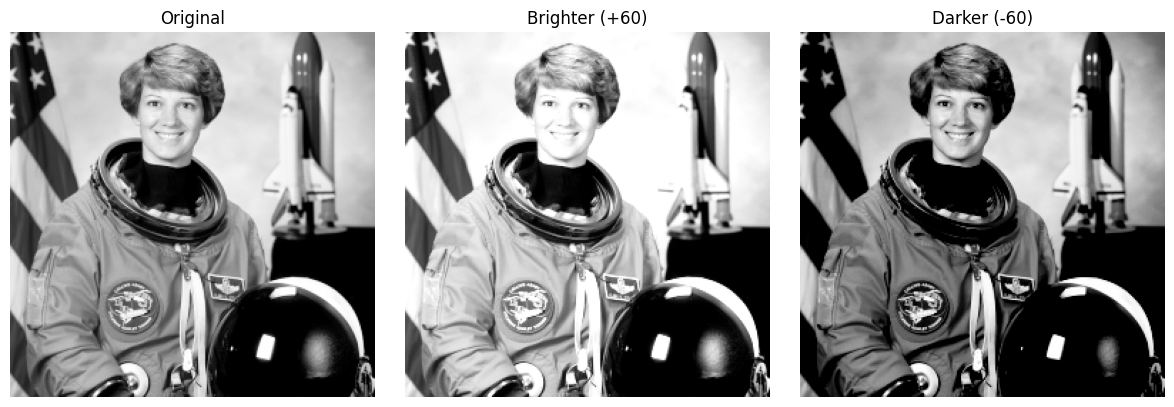

In [11]:
# Increase brightness by adding a constant, using np.clip to stay within [0, 255]
brighter = np.clip(img_array.astype(int) + 60, 0, 255).astype(np.uint8)

# Decrease brightness
darker = np.clip(img_array.astype(int) - 60, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_array, cmap=cm.Greys_r); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(brighter, cmap=cm.Greys_r); axes[1].set_title("Brighter (+60)"); axes[1].axis('off')
axes[2].imshow(darker, cmap=cm.Greys_r); axes[2].set_title("Darker (-60)"); axes[2].axis('off')
plt.tight_layout()
plt.show()


### 5) Thresholding (binary image)

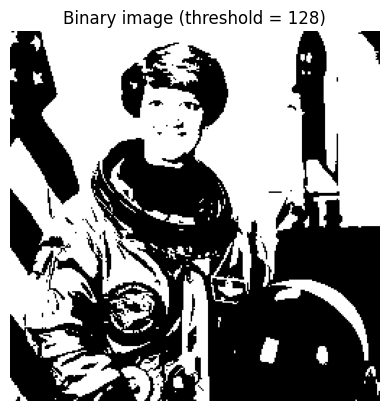

In [12]:
threshold = 128
binary_image = np.where(img_array > threshold, 255, 0).astype(np.uint8)

plt.imshow(binary_image, cmap=cm.Greys_r)
plt.title(f"Binary image (threshold = {threshold})")
plt.axis('off')
plt.show()


### 6) Basic statistics on the array

In [13]:
print("Minimum pixel value :", img_array.min())
print("Maximum pixel value :", img_array.max())
print("Mean pixel value     :", img_array.mean())
print("Standard deviation   :", img_array.std())


Minimum pixel value : 0
Maximum pixel value : 255
Mean pixel value     : 115.51615905761719
Standard deviation   : 74.49099706618347


## Conclusion

In this lab we:
- Installed/configured the Python image-processing environment (Anaconda, Jupyter, OpenCV, PIL, NumPy, Matplotlib).
- Loaded and visualized images using both **OpenCV** and **PIL**.
- Saved images to disk using both libraries.
- Represented an image as a **NumPy array** and inspected its shape/values.
- Performed several NumPy operations on the image array: slicing/cropping, flipping,
  rotating, brightness adjustment, thresholding, and basic statistics.
